In [1]:
# Imports
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

%matplotlib inline


# Tổng hợp kết quả

In [4]:
test_probs_resnet = pd.read_csv(
    r"D:\OneDrive - fpts.com.vn\DucNN privates\Files\Khoa học dữ liệu\Chuyen_de_4_Hoc_sau_va_ung_dung_trong_bai_toan_anh\data\prepared_data\test_probs_resnet.csv"
)
test_probs_resnet
test_labels_resnet = pd.read_csv(
    r"D:\OneDrive - fpts.com.vn\DucNN privates\Files\Khoa học dữ liệu\Chuyen_de_4_Hoc_sau_va_ung_dung_trong_bai_toan_anh\data\prepared_data\test_labels_resnet.csv"
)
test_labels_resnet

,id,label
0,c0596dc779612db5477d6a2e3770d61732c202e7,1
1,13682039e848c6e473c54619365b23ffcab50e2c,1
2,c15f7233e2e9b87fe7297f72329199a6527fd7a9,0
3,540ee2788f05d170ab314cf30e5227275b9e1a3d,0
4,d9f4cdcfd9b2a7195d5c8d1a17905090b79bd75f,0
...,...,...
4396,dc45b865d6ffee13a9b62056b3f3bacd4ef42f21,0
4397,379849390dcd66b26449c834921e862c24dc1081,0
4398,6e90de1fe713073d7574ebdf6f9b790dbb2d278c,1
4399,ba957dffe2d1b56e024b1fdb25ee216f3718d979,0


Loaded 4401 probability predictions
Loaded 4401 true labels

✓ Saved predictions to: D:\OneDrive - fpts.com.vn\DucNN privates\Files\Khoa học dữ liệu\Chuyen_de_4_Hoc_sau_va_ung_dung_trong_bai_toan_anh\data\prepared_data\test_predictions_resnet.csv
✓ Successfully matched 4401 samples



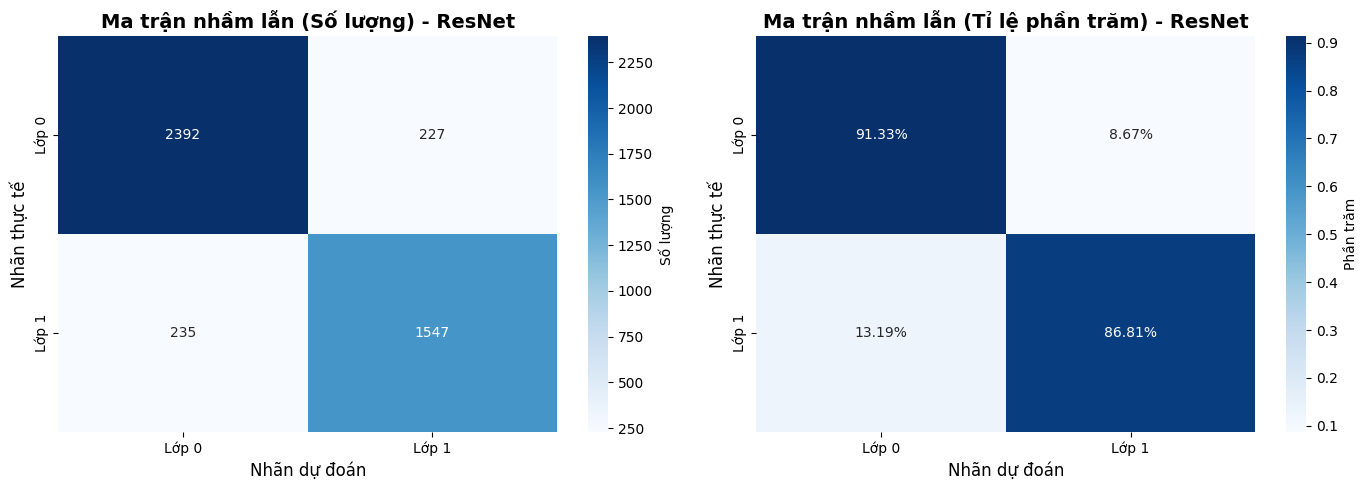


Báo cáo phân loại - Model: ResNet
              precision    recall  f1-score   support

       Lớp 0       0.91      0.91      0.91      2619
       Lớp 1       0.87      0.87      0.87      1782

    accuracy                           0.90      4401
   macro avg       0.89      0.89      0.89      4401
weighted avg       0.89      0.90      0.89      4401


Giải thích các chỉ số F1:
F1 cho Lớp 0 (pos_label=0):  0.91193
F1 cho Lớp 1 (pos_label=1):  0.87008
F1 binary (mặc định, cho Lớp 1):  0.87008
F1 macro (trung bình đơn giản):  0.89101
F1 weighted (trung bình có trọng số):  0.89499

Chi tiết ma trận nhầm lẫn:
Số âm thực sự (TN):  2392
Số dương giả (FP): 227
Số âm giả (FN): 235
Số dương thực sự (TP):  1547

Tổng số mẫu: 4401


In [5]:
# Convert ResNet probabilities to predictions and calculate stats
DATA_FOLDER = r"D:\OneDrive - fpts.com.vn\DucNN privates\Files\Khoa học dữ liệu\Chuyen_de_4_Hoc_sau_va_ung_dung_trong_bai_toan_anh\data\prepared_data"

# Load probabilities and true labels
test_probs_resnet = pd.read_csv(os.path.join(DATA_FOLDER, "test_probs_resnet.csv"))
test_labels_resnet = pd.read_csv(os.path.join(DATA_FOLDER, "test_labels_resnet.csv"))

print(f"Loaded {len(test_probs_resnet)} probability predictions")
print(f"Loaded {len(test_labels_resnet)} true labels")

# Convert probabilities to binary predictions (threshold = 0.5)
test_predictions_resnet = test_probs_resnet.copy()
test_predictions_resnet["label"] = (test_probs_resnet["label"] >= 0.5).astype(int)

# Save predictions to CSV
output_path = os.path.join(DATA_FOLDER, "test_predictions_resnet.csv")
test_predictions_resnet.to_csv(output_path, index=False)
print(f"\n✓ Saved predictions to: {output_path}")

# Merge predictions with true labels on 'id' column
merged_df = test_labels_resnet.merge(
    test_predictions_resnet, on="id", suffixes=("_true", "_pred")
)
y_true = merged_df["label_true"].values
y_pred = merged_df["label_pred"].values
print(f"✓ Successfully matched {len(merged_df)} samples\n")

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Vietnamese translation labels
vn_xticklabels = ["Lớp 0", "Lớp 1"]
vn_yticklabels = ["Lớp 0", "Lớp 1"]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion matrix with counts
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=vn_xticklabels,
    yticklabels=vn_yticklabels,
    ax=axes[0],
    cbar_kws={"label": "Số lượng"},
)
axes[0].set_xlabel("Nhãn dự đoán", fontsize=12)
axes[0].set_ylabel("Nhãn thực tế", fontsize=12)
axes[0].set_title(
    "Ma trận nhầm lẫn (Số lượng) - ResNet", fontsize=14, fontweight="bold"
)

# Plot 2: Normalized confusion matrix (percentages)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=vn_xticklabels,
    yticklabels=vn_yticklabels,
    ax=axes[1],
    cbar_kws={"label": "Phần trăm"},
)
axes[1].set_xlabel("Nhãn dự đoán", fontsize=12)
axes[1].set_ylabel("Nhãn thực tế", fontsize=12)
axes[1].set_title(
    "Ma trận nhầm lẫn (Tỉ lệ phần trăm) - ResNet", fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.show()

# Print classification report
print(f"\n{'=' * 60}")
print("Báo cáo phân loại - Model: ResNet")
print(f"{'=' * 60}")
print(classification_report(y_true, y_pred, target_names=["Lớp 0", "Lớp 1"]))

# Compute and print explicit F1 scores for comparison
f1_class0 = f1_score(y_true, y_pred, pos_label=0)
f1_class1 = f1_score(y_true, y_pred, pos_label=1)
f1_binary = f1_score(y_true, y_pred, average="binary")  # Same as pos_label=1 for binary
f1_weighted = f1_score(y_true, y_pred, average="weighted")
f1_macro = f1_score(y_true, y_pred, average="macro")

print("\nGiải thích các chỉ số F1:")
print("=" * 60)
print(f"F1 cho Lớp 0 (pos_label=0):  {f1_class0:.5f}")
print(f"F1 cho Lớp 1 (pos_label=1):  {f1_class1:.5f}")
print(f"F1 binary (mặc định, cho Lớp 1):  {f1_binary:.5f}")
print(f"F1 macro (trung bình đơn giản):  {f1_macro:.5f}")
print(f"F1 weighted (trung bình có trọng số):  {f1_weighted:.5f}")

# Print confusion matrix details
tn, fp, fn, tp = cm.ravel()
print("\nChi tiết ma trận nhầm lẫn:")
print("=" * 60)
print(f"Số âm thực sự (TN):  {tn}")
print(f"Số dương giả (FP): {fp}")
print(f"Số âm giả (FN): {fn}")
print(f"Số dương thực sự (TP):  {tp}")
print(f"\nTổng số mẫu: {len(y_true)}")


In [6]:
# Configuration: Select which model results to analyze
# Available models:
# - "cnn" -> test_predictions_cnn.csv
# - "densenet_val_False" -> test_predictions_densenet_val_False.csv
# - "densenet_val_True" -> test_predictions_densenet_val_True.csv
# - "densenet_val_True_furthertuning_False" -> test_predictions_densenet_val_True_furthertuning_False.csv

MODEL_NAME = "vit_s16"  # Change this to switch between models

# Data paths
DATA_FOLDER = r"D:\OneDrive - fpts.com.vn\DucNN privates\Files\Khoa học dữ liệu\Chuyen_de_4_Hoc_sau_va_ung_dung_trong_bai_toan_anh\data\prepared_data"

# Map model names to CSV filenames
MODEL_TO_CSV = {
    "cnn": "test_predictions_cnn.csv",
    # "densenet_val_False": "test_predictions_densenet_val_False.csv",
    # "densenet_val_True": "test_predictions_densenet_val_True.csv",
    "densenet169": "test_predictions_densenet_val_True_furthertuning_False.csv",
    "densenet121": "test_predictions_densenet121.csv",
    "vit_s16": "test_predictions_vit_s16.csv",
    "resnet": "test_predictions_resnet.csv",
}

# Get the prediction CSV filename
pred_csv_filename = MODEL_TO_CSV.get(MODEL_NAME)
if pred_csv_filename is None:
    available_models = ", ".join(MODEL_TO_CSV.keys())
    raise ValueError(
        f"Unknown model name: {MODEL_NAME}. Available models: {available_models}"
    )

pred_csv_path = os.path.join(DATA_FOLDER, pred_csv_filename)
test_labels_path = os.path.join(DATA_FOLDER, "test_labels.csv")

print(f"Selected model: {MODEL_NAME}")
print(f"Loading predictions from: {pred_csv_path}")
print(f"Loading true labels from: {test_labels_path}")

Selected model: vit_s16
Loading predictions from: D:\OneDrive - fpts.com.vn\DucNN privates\Files\Khoa học dữ liệu\Chuyen_de_4_Hoc_sau_va_ung_dung_trong_bai_toan_anh\data\prepared_data\test_predictions_vit_s16.csv
Loading true labels from: D:\OneDrive - fpts.com.vn\DucNN privates\Files\Khoa học dữ liệu\Chuyen_de_4_Hoc_sau_va_ung_dung_trong_bai_toan_anh\data\prepared_data\test_labels.csv


In [ ]:
# Compare all models: Loop through all models and compute F1 scores
DATA_FOLDER = r"D:\OneDrive - fpts.com.vn\DucNN privates\Files\Khoa học dữ liệu\Chuyen_de_4_Hoc_sau_va_ung_dung_trong_bai_toan_anh\data\prepared_data"

# Default test labels path
default_test_labels_path = os.path.join(DATA_FOLDER, "test_labels.csv")
# ResNet uses a different test set
resnet_test_labels_path = os.path.join(DATA_FOLDER, "test_labels_resnet.csv")

# Load default true labels once (for most models)
test_df = pd.read_csv(default_test_labels_path)

# Store results for all models
results_list = []

print("Processing all models...\n")
for model_name, csv_filename in MODEL_TO_CSV.items():
    pred_csv_path = os.path.join(DATA_FOLDER, csv_filename)

    # Check if file exists
    if not os.path.exists(pred_csv_path):
        print(f"Warning: {csv_filename} not found, skipping {model_name}")
        continue

    try:
        # Load predictions
        pred_df = pd.read_csv(pred_csv_path)

        # Use different labels file for ResNet model
        if model_name == "resnet":
            test_df_model = pd.read_csv(resnet_test_labels_path)
        else:
            test_df_model = test_df

        # Merge with true labels
        if "label" in test_df_model.columns and "label" in pred_df.columns:
            merged_df = test_df_model.merge(
                pred_df, on="id", suffixes=("_true", "_pred")
            )
            y_true = merged_df["label_true"].values
            y_pred = merged_df["label_pred"].values

            # Compute F1 scores
            f1_class0 = f1_score(y_true, y_pred, pos_label=0)
            f1_class1 = f1_score(y_true, y_pred, pos_label=1)
            f1_weighted = f1_score(y_true, y_pred, average="weighted")

            results_list.append(
                {
                    "Model": model_name,
                    "F1 Class 0": f1_class0,
                    "F1 Class 1": f1_class1,
                    "F1 Weighted Avg": f1_weighted,
                }
            )
            print(f"✓ Processed {model_name}")
        else:
            print(f"Warning: Missing required columns for {model_name}")
    except Exception as e:
        print(f"Error processing {model_name}: {str(e)}")

# Create DataFrame and display
if results_list:
    results_df = pd.DataFrame(results_list)

    # Sort by weighted average F1 (descending) while values are still numeric
    results_df = results_df.sort_values("F1 Weighted Avg", ascending=False).reset_index(
        drop=True
    )

    # Create a copy for display with formatted values
    results_display = results_df.copy()
    results_display["F1 Class 0"] = results_display["F1 Class 0"].apply(
        lambda x: f"{x:.5f}"
    )
    results_display["F1 Class 1"] = results_display["F1 Class 1"].apply(
        lambda x: f"{x:.5f}"
    )
    results_display["F1 Weighted Avg"] = results_display["F1 Weighted Avg"].apply(
        lambda x: f"{x:.5f}"
    )

    print("\n" + "=" * 70)
    print("Comparison Table: F1 Scores for All Models")
    print("=" * 70)
    print(results_display.to_string(index=False))
    print("=" * 70)

    # Also display as a styled table
    display(
        results_display.style.set_table_styles(
            [
                {
                    "selector": "thead th",
                    "props": [
                        ("background-color", "#4472C4"),
                        ("color", "white"),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                    ],
                },
                {"selector": "tbody td", "props": [("text-align", "center")]},
            ]
        ).set_caption("Model Comparison: F1 Scores (sorted by F1 Weighted Avg)")
    )

    print("\nNote: Results are sorted by F1 Weighted Avg (descending)")
    print(
        f"Best model: {results_df.iloc[0]['Model']} (F1 Weighted Avg = {results_df.iloc[0]['F1 Weighted Avg']:.5f})"
    )
else:
    print("No results to display.")

Processing all models...

✓ Processed cnn
✓ Processed densenet169
✓ Processed densenet121
✓ Processed vit_s16
✓ Processed resnet

Comparison Table: F1 Scores for All Models
      Model F1 Class 0 F1 Class 1 F1 Weighted Avg
    vit_s16    0.95064    0.92722         0.94120
densenet169    0.94425    0.91306         0.93162
densenet121    0.93213    0.89740         0.91813
        cnn    0.91287    0.87152         0.89613
     resnet    0.90580    0.85792         0.88650


,Model,F1 Class 0,F1 Class 1,F1 Weighted Avg
0,vit_s16,0.95064,0.92722,0.94120
1,densenet169,0.94425,0.91306,0.93162
2,densenet121,0.93213,0.89740,0.91813
3,cnn,0.91287,0.87152,0.89613
4,resnet,0.90580,0.85792,0.88650



Note: Results are sorted by F1 Weighted Avg (descending)
Best model: vit_s16 (F1 Weighted Avg = 0.94120)


# Kết quả chi tiết model

In [47]:
# Load predictions and true labels
if not os.path.exists(pred_csv_path):
    raise FileNotFoundError(f"Predictions file not found: {pred_csv_path}")

if not os.path.exists(test_labels_path):
    raise FileNotFoundError(f"Test labels file not found: {test_labels_path}")

# Load predictions
pred_df = pd.read_csv(pred_csv_path)
print(f"Loaded {len(pred_df)} predictions from CSV")

# Load true labels
test_df = pd.read_csv(test_labels_path)
print(f"Loaded {len(test_df)} true labels from CSV")

# Merge predictions with true labels on 'id' column
if "label" in test_df.columns and "label" in pred_df.columns:
    merged_df = test_df.merge(pred_df, on="id", suffixes=("_true", "_pred"))
    y_true = merged_df["label_true"].values
    y_pred = merged_df["label_pred"].values
    print(f"Successfully matched {len(merged_df)} samples")
else:
    raise ValueError("Required 'id' and 'label' columns not found in CSVs")

Loaded 4401 predictions from CSV
Loaded 4401 true labels from CSV
Successfully matched 918 samples


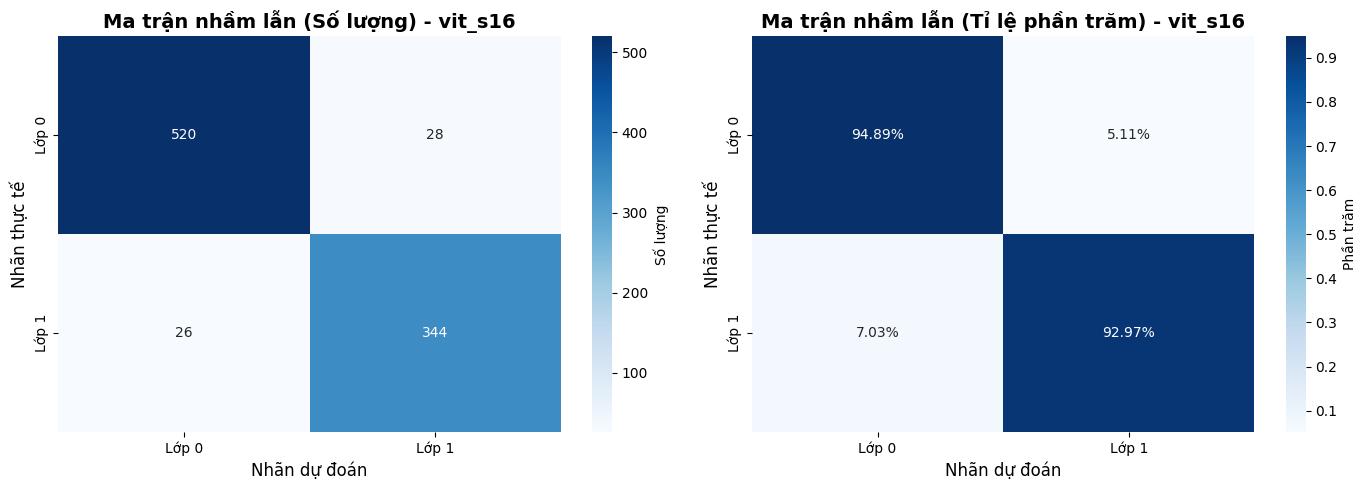

In [48]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Vietnamese translation labels
vn_xticklabels = ["Lớp 0", "Lớp 1"]
vn_yticklabels = ["Lớp 0", "Lớp 1"]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion matrix with counts
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=vn_xticklabels,
    yticklabels=vn_yticklabels,
    ax=axes[0],
    cbar_kws={"label": "Số lượng"},
)
axes[0].set_xlabel("Nhãn dự đoán", fontsize=12)
axes[0].set_ylabel("Nhãn thực tế", fontsize=12)
axes[0].set_title(
    f"Ma trận nhầm lẫn (Số lượng) - {MODEL_NAME}", fontsize=14, fontweight="bold"
)

# Plot 2: Normalized confusion matrix (percentages)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=vn_xticklabels,
    yticklabels=vn_yticklabels,
    ax=axes[1],
    cbar_kws={"label": "Phần trăm"},
)
axes[1].set_xlabel("Nhãn dự đoán", fontsize=12)
axes[1].set_ylabel("Nhãn thực tế", fontsize=12)
axes[1].set_title(
    f"Ma trận nhầm lẫn (Tỉ lệ phần trăm) - {MODEL_NAME}", fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [49]:
# Print classification report
print(f"\n{'=' * 60}")
print(f"Báo cáo phân loại - Model: {MODEL_NAME}")
print(f"{'=' * 60}")
print(classification_report(y_true, y_pred, target_names=["Lớp 0", "Lớp 1"]))

# Compute and print explicit F1 scores for comparison
f1_class0 = f1_score(y_true, y_pred, pos_label=0)
f1_class1 = f1_score(y_true, y_pred, pos_label=1)
f1_binary = f1_score(y_true, y_pred, average="binary")  # Same as pos_label=1 for binary
f1_weighted = f1_score(y_true, y_pred, average="weighted")
f1_macro = f1_score(y_true, y_pred, average="macro")

print("\nGiải thích các chỉ số F1:")
print("=" * 60)
print(f"F1 cho Lớp 0 (pos_label=0):  {f1_class0:.5f}")
print(f"F1 cho Lớp 1 (pos_label=1):  {f1_class1:.5f}")
print(f"F1 binary (mặc định, cho Lớp 1):  {f1_binary:.5f}")
print(f"F1 macro (trung bình đơn giản):  {f1_macro:.5f}")
print(f"F1 weighted (trung bình có trọng số):  {f1_weighted:.5f}")

# Print confusion matrix details
tn, fp, fn, tp = cm.ravel()
print("\nChi tiết ma trận nhầm lẫn:")
print("=" * 60)
print(f"Số âm thực sự (TN):  {tn}")
print(f"Số dương giả (FP): {fp}")
print(f"Số âm giả (FN): {fn}")
print(f"Số dương thực sự (TP):  {tp}")
print(f"\nTổng số mẫu: {len(y_true)}")


Báo cáo phân loại - Model: vit_s16
              precision    recall  f1-score   support

       Lớp 0       0.95      0.95      0.95       548
       Lớp 1       0.92      0.93      0.93       370

    accuracy                           0.94       918
   macro avg       0.94      0.94      0.94       918
weighted avg       0.94      0.94      0.94       918


Giải thích các chỉ số F1:
F1 cho Lớp 0 (pos_label=0):  0.95064
F1 cho Lớp 1 (pos_label=1):  0.92722
F1 binary (mặc định, cho Lớp 1):  0.92722
F1 macro (trung bình đơn giản):  0.93893
F1 weighted (trung bình có trọng số):  0.94120

Chi tiết ma trận nhầm lẫn:
Số âm thực sự (TN):  520
Số dương giả (FP): 28
Số âm giả (FN): 26
Số dương thực sự (TP):  344

Tổng số mẫu: 918
